In [2]:
import pandas as pd
import numpy as np 

In [76]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel("GEOPOLYMER_CONCRETE_24_2_24 copy.xlsx", header=[0,1,2,3])
df.head()

,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,Unnamed: 10_level_0,Harden Properties
,S.No,Author/s,MIXED,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,OUTPUT
,Unnamed: 0_level_2,Unnamed: 1_level_2,Number,Binders (kg/m3),Extra Water (kg/m3),Alkaline Solution (Kg/m3),Molarity of mix,FA (kg/m3),CA (kg/m3),Age (days),Curing temperature (Degree Celsius),Compressive Strenght (MPa)
,Unnamed: 0_level_3,Unnamed: 1_level_3,Unnamed: 2_level_3,Unnamed: 3_level_3,Unnamed: 4_level_3,Unnamed: 5_level_3,Unnamed: 6_level_3,Unnamed: 7_level_3,Unnamed: 8_level_3,Unnamed: 9_level_3,Unnamed: 10_level_3,Unnamed: 11_level_3
0,1.0,"Vora et al., 2013",1,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,30.0
1,NaN,NaN,2,444.0,43.0,155.0,14.0,630.0,1170.0,1.0,75.0,30.0
2,NaN,NaN,3,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,40.0
3,NaN,NaN,4,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,28.0
4,NaN,NaN,5,428.0,43.0,171.0,14.0,630.0,1170.0,2.0,75.0,32.0


In [4]:
df.tail()

,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,Unnamed: 10_level_0,Harden Properties
,S.No,Author/s,MIXED,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,OUTPUT
,Unnamed: 0_level_2,Unnamed: 1_level_2,Number,Binders (kg/m3),Extra Water (kg/m3),Alkaline Solution (Kg/m3),Molarity of mix,FA (kg/m3),CA (kg/m3),Age (days),Curing temperature (Degree Celsius),Compressive Strenght (MPa)
,Unnamed: 0_level_3,Unnamed: 1_level_3,Unnamed: 2_level_3,Unnamed: 3_level_3,Unnamed: 4_level_3,Unnamed: 5_level_3,Unnamed: 6_level_3,Unnamed: 7_level_3,Unnamed: 8_level_3,Unnamed: 9_level_3,Unnamed: 10_level_3,Unnamed: 11_level_3
2102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2104,NaN,NaN,MINIMUM VALUE,134.120000,0.000000,65.000000,4.100000,328.500000,647.800000,1.000000,20.000000,1.10000
2105,NaN,NaN,MAXIMUM VALUE,666.000000,145.000000,384.430000,42.000000,1675.000000,3270.000000,365.000000,900.000000,110.00000
2106,NaN,NaN,AVERAGE VALUE,405.252535,16.684208,183.579191,11.971442,678.675093,1172.222798,28.962626,45.015333,38.48216


In [5]:
df.shape

(2107, 12)

In [6]:
df_summary = df.tail(3).copy()
df_summary

,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,Unnamed: 10_level_0,Harden Properties
,S.No,Author/s,MIXED,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,OUTPUT
,Unnamed: 0_level_2,Unnamed: 1_level_2,Number,Binders (kg/m3),Extra Water (kg/m3),Alkaline Solution (Kg/m3),Molarity of mix,FA (kg/m3),CA (kg/m3),Age (days),Curing temperature (Degree Celsius),Compressive Strenght (MPa)
,Unnamed: 0_level_3,Unnamed: 1_level_3,Unnamed: 2_level_3,Unnamed: 3_level_3,Unnamed: 4_level_3,Unnamed: 5_level_3,Unnamed: 6_level_3,Unnamed: 7_level_3,Unnamed: 8_level_3,Unnamed: 9_level_3,Unnamed: 10_level_3,Unnamed: 11_level_3
2104,NaN,NaN,MINIMUM VALUE,134.120000,0.000000,65.000000,4.100000,328.500000,647.800000,1.000000,20.000000,1.10000
2105,NaN,NaN,MAXIMUM VALUE,666.000000,145.000000,384.430000,42.000000,1675.000000,3270.000000,365.000000,900.000000,110.00000
2106,NaN,NaN,AVERAGE VALUE,405.252535,16.684208,183.579191,11.971442,678.675093,1172.222798,28.962626,45.015333,38.48216


The last entries of the dataset contains the summary statistics.... So efficient removal is important to make this dataframe eligible for processing...

In [7]:
df_summary = df.tail(3).copy()

main_df = df[pd.to_numeric(df.iloc[:, 2], errors='coerce').notnull()]

main_df = main_df.dropna(how='all', axis=1)

print(f"Cleaned dataset shape: {main_df.shape}")
print(f"Summary stats shape: {df_summary.shape}")

Cleaned dataset shape: (2100, 12)
Summary stats shape: (3, 12)


In [8]:
main_df.head()


,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,Unnamed: 10_level_0,Harden Properties
,S.No,Author/s,MIXED,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,OUTPUT
,Unnamed: 0_level_2,Unnamed: 1_level_2,Number,Binders (kg/m3),Extra Water (kg/m3),Alkaline Solution (Kg/m3),Molarity of mix,FA (kg/m3),CA (kg/m3),Age (days),Curing temperature (Degree Celsius),Compressive Strenght (MPa)
,Unnamed: 0_level_3,Unnamed: 1_level_3,Unnamed: 2_level_3,Unnamed: 3_level_3,Unnamed: 4_level_3,Unnamed: 5_level_3,Unnamed: 6_level_3,Unnamed: 7_level_3,Unnamed: 8_level_3,Unnamed: 9_level_3,Unnamed: 10_level_3,Unnamed: 11_level_3
0,1.0,"Vora et al., 2013",1,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,30.0
1,NaN,NaN,2,444.0,43.0,155.0,14.0,630.0,1170.0,1.0,75.0,30.0
2,NaN,NaN,3,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,40.0
3,NaN,NaN,4,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,28.0
4,NaN,NaN,5,428.0,43.0,171.0,14.0,630.0,1170.0,2.0,75.0,32.0


In [9]:
main_df.tail()

,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,Unnamed: 10_level_0,Harden Properties
,S.No,Author/s,MIXED,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,OUTPUT
,Unnamed: 0_level_2,Unnamed: 1_level_2,Number,Binders (kg/m3),Extra Water (kg/m3),Alkaline Solution (Kg/m3),Molarity of mix,FA (kg/m3),CA (kg/m3),Age (days),Curing temperature (Degree Celsius),Compressive Strenght (MPa)
,Unnamed: 0_level_3,Unnamed: 1_level_3,Unnamed: 2_level_3,Unnamed: 3_level_3,Unnamed: 4_level_3,Unnamed: 5_level_3,Unnamed: 6_level_3,Unnamed: 7_level_3,Unnamed: 8_level_3,Unnamed: 9_level_3,Unnamed: 10_level_3,Unnamed: 11_level_3
2095,NaN,NaN,2097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2096,NaN,NaN,2098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2097,NaN,NaN,2099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2098,NaN,NaN,2100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2099,NaN,NaN,2101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Indexing with empty entries are found... So we remove the empty entries

In [10]:
main_df = main_df.dropna(subset=[main_df.columns[3]])

main_df.tail()

,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,Unnamed: 10_level_0,Harden Properties
,S.No,Author/s,MIXED,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,OUTPUT
,Unnamed: 0_level_2,Unnamed: 1_level_2,Number,Binders (kg/m3),Extra Water (kg/m3),Alkaline Solution (Kg/m3),Molarity of mix,FA (kg/m3),CA (kg/m3),Age (days),Curing temperature (Degree Celsius),Compressive Strenght (MPa)
,Unnamed: 0_level_3,Unnamed: 1_level_3,Unnamed: 2_level_3,Unnamed: 3_level_3,Unnamed: 4_level_3,Unnamed: 5_level_3,Unnamed: 6_level_3,Unnamed: 7_level_3,Unnamed: 8_level_3,Unnamed: 9_level_3,Unnamed: 10_level_3,Unnamed: 11_level_3
2082,NaN,NaN,2084,460.0,32.0,180.0,12.0,512.0,1181.0,90.0,27.0,45.57
2083,NaN,NaN,2085,520.0,32.0,180.0,12.0,465.0,1181.0,90.0,27.0,71.27
2084,NaN,NaN,2086,520.0,32.0,180.0,12.0,465.0,1181.0,90.0,27.0,64.71
2085,NaN,NaN,2087,520.0,32.0,180.0,12.0,465.0,1181.0,90.0,27.0,58.81
2086,NaN,NaN,2088,520.0,32.0,180.0,12.0,465.0,1181.0,90.0,27.0,46.35


Multiheader columns should be reduced to the single heading columns

In [11]:
main_df.columns = ["s.no", "authors", "number", "binders", "extra water", "alkaline solution", "molarity of mix", "fine aggregate", "coarse aggregate", "age", "curing temperature", "compressive strength"]

main_df.columns

Index(['s.no', 'authors', 'number', 'binders', 'extra water',
       'alkaline solution', 'molarity of mix', 'fine aggregate',
       'coarse aggregate', 'age', 'curing temperature',
       'compressive strength'],
      dtype='object')

In [12]:
main_df.head()


,s.no,authors,number,binders,extra water,alkaline solution,molarity of mix,fine aggregate,coarse aggregate,age,curing temperature,compressive strength
0,1.0,"Vora et al., 2013",1,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,30.0
1,NaN,NaN,2,444.0,43.0,155.0,14.0,630.0,1170.0,1.0,75.0,30.0
2,NaN,NaN,3,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,40.0
3,NaN,NaN,4,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,28.0
4,NaN,NaN,5,428.0,43.0,171.0,14.0,630.0,1170.0,2.0,75.0,32.0


In [13]:
main_df = main_df.iloc[:, 3:]
print(f"Final shape for ML: {main_df.shape}")
main_df.head()

Final shape for ML: (2087, 9)


,binders,extra water,alkaline solution,molarity of mix,fine aggregate,coarse aggregate,age,curing temperature,compressive strength
0,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,30.0
1,444.0,43.0,155.0,14.0,630.0,1170.0,1.0,75.0,30.0
2,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,40.0
3,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,28.0
4,428.0,43.0,171.0,14.0,630.0,1170.0,2.0,75.0,32.0


In [14]:
main_df.isnull().sum()

binders                 0
extra water             0
alkaline solution       0
molarity of mix         0
fine aggregate          0
coarse aggregate        0
age                     0
curing temperature      0
compressive strength    0
dtype: int64

In [15]:
main_df.duplicated().sum()

np.int64(30)

Dropping the duplicates (same entries...)

In [16]:
main_df.drop_duplicates(inplace=True)

In [17]:
main_df.shape

(2057, 9)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_dataset(df, dataset_name):
    print(f"--- Exploratory Data Analysis for {dataset_name} ---")
    
    plt.figure(figsize=(10, 8))
    
    target = 'compressive strength'
    if target in df.columns:
        features = [col for col in df.columns if col != target]
        fig, axes = plt.subplots(nrows=int(len(features)/3) + 1, ncols=3, figsize=(15, 12))
        axes = axes.flatten()
        
        for i, col in enumerate(features):
            sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{col} vs {target}')
            
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df, orient="h", palette="Set2")
    plt.title(f'Boxplots (Outlier Detection) - {dataset_name}')
    plt.tight_layout()
    plt.show()
    

    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(f'Correlation Matrix - {dataset_name}')
    plt.show()
    
    
    num_cols = len(df.columns)
    df.hist(bins=30, figsize=(15, 12), layout=(int(num_cols/3) + 1, 3))
    plt.suptitle(f'Histograms (Distributions) - {dataset_name}', fontsize=16)
    plt.tight_layout()
    plt.show()


Here, we are implementing the manual outlier removal of the dataset...

Age <= 175 days (beyond which strength gains plateau and data becomes sparse)

Extra water < 130 kg/m3 (consistent with practical alkaline activator preparation)

Alkaline solution: 100 < value <= 300 kg/m3

Molarity of mix <= 20 mol/L (higher concentrations are rarely used in practice)

Binder < 600 kg/m3 (beyond which workability becomes impractical)

Compressive strength > 0 MPa (removes zero-strength erroneous entries)

Curing temperature < 90 degrees C

Coarse aggregate < 1,400 kg/m3

Fine aggregate < 1,100 kg/m3

original number of rows:  2057
Geopolymer after cleaning: 1662 rows

--- Exploratory Data Analysis for Geopolymer Concrete (geo_df) ---


<Figure size 1000x800 with 0 Axes>

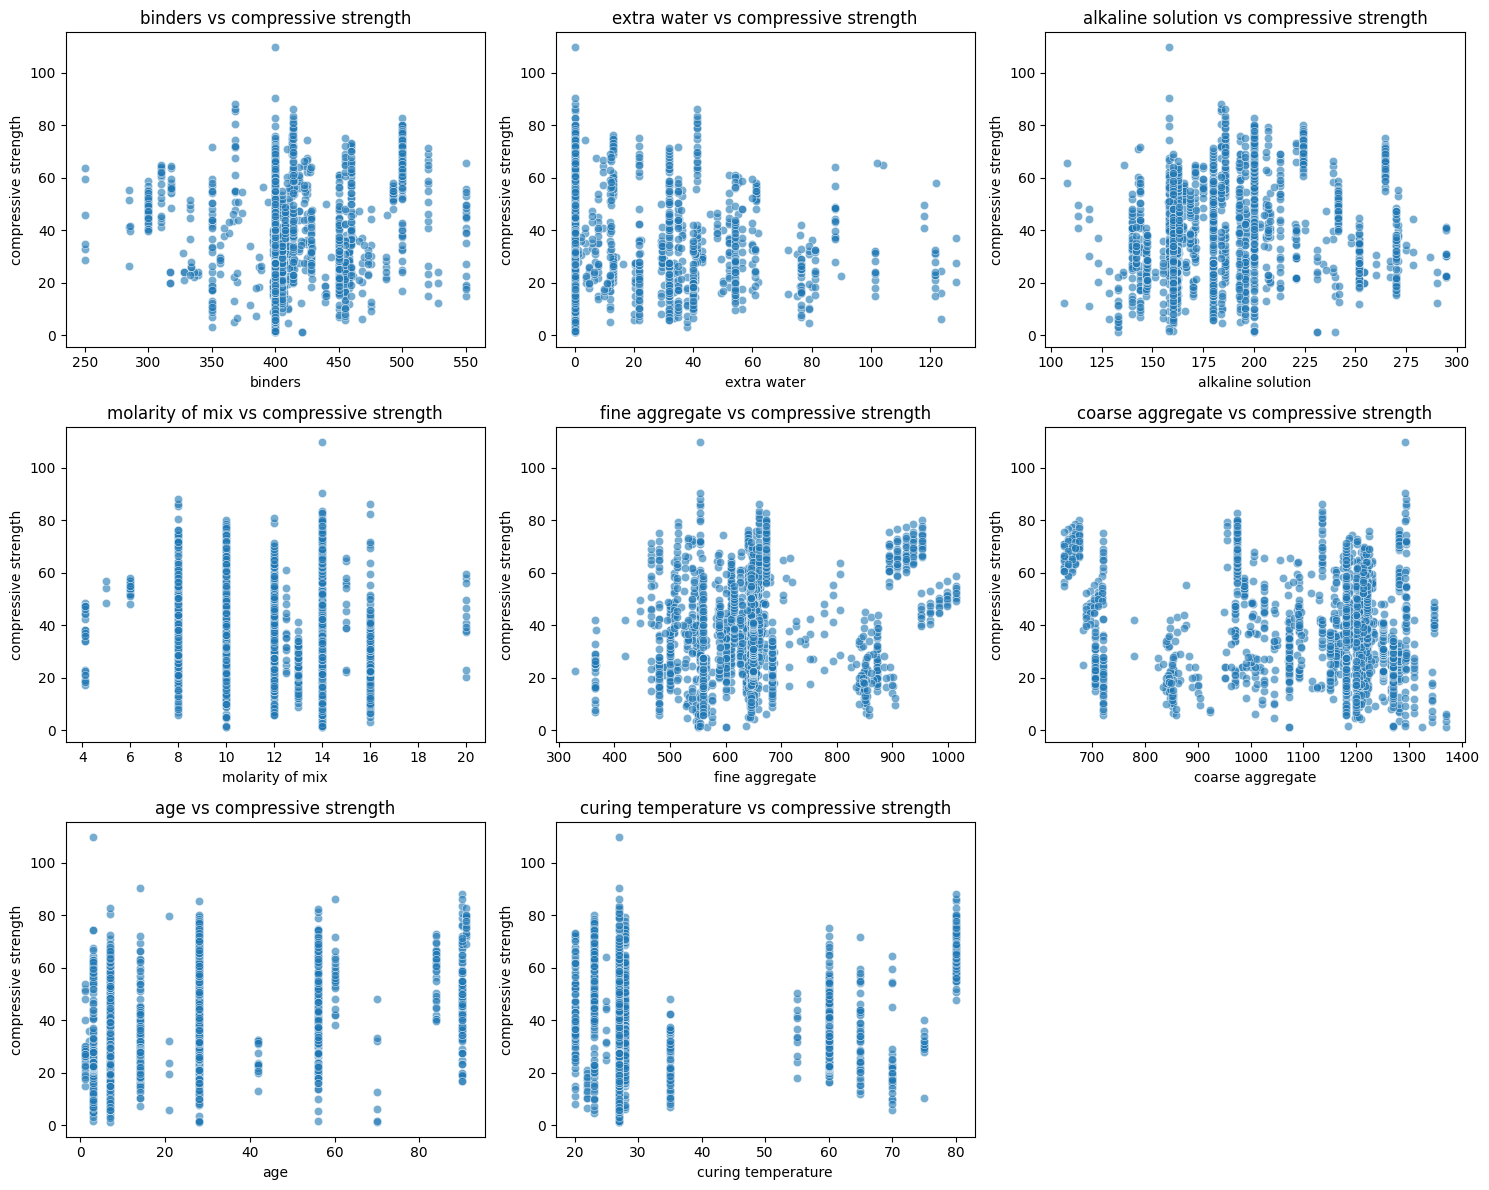

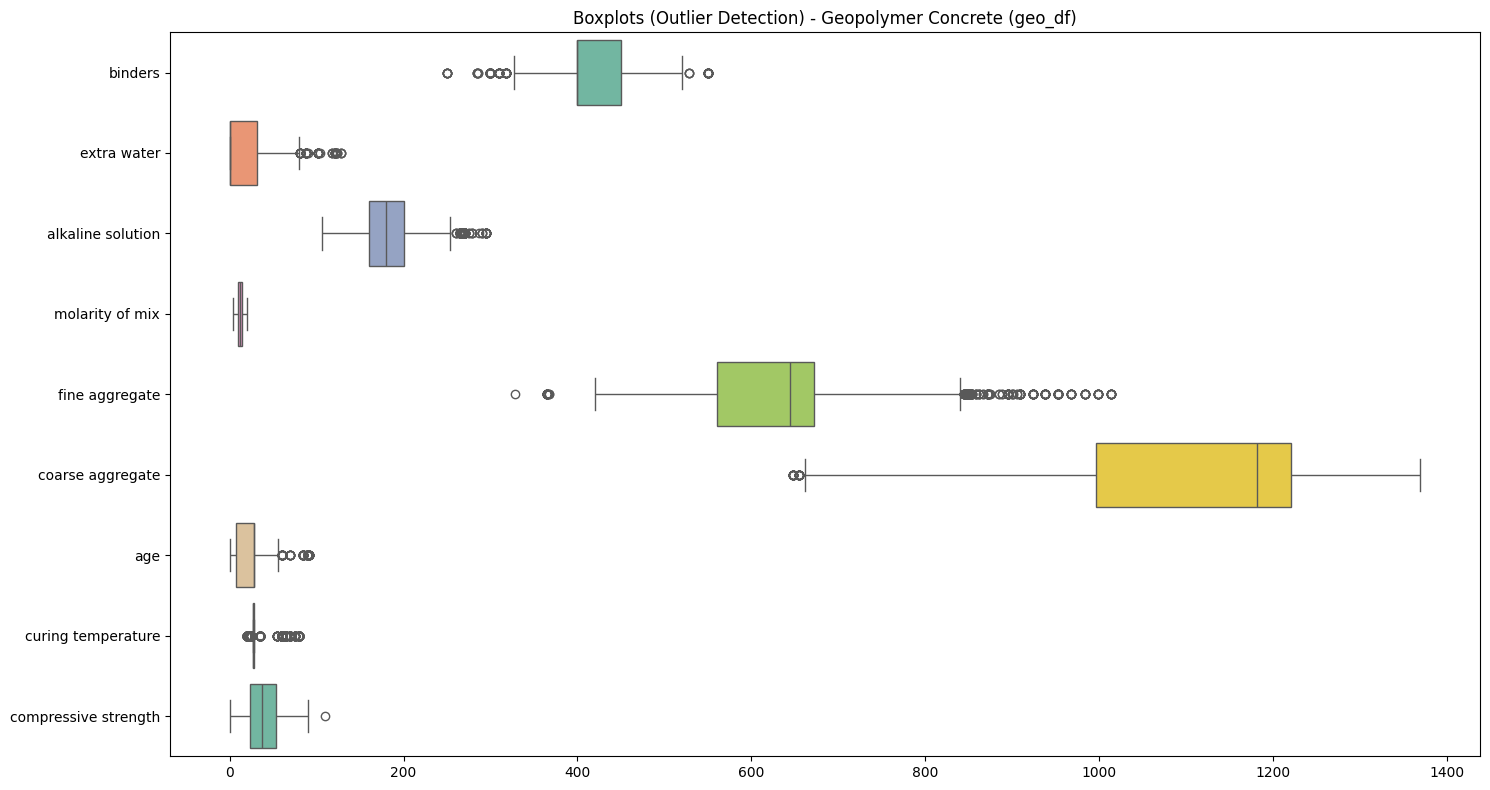

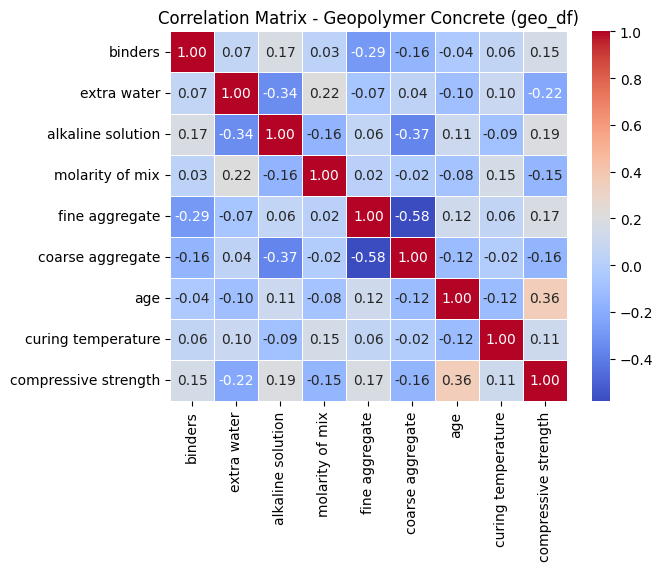

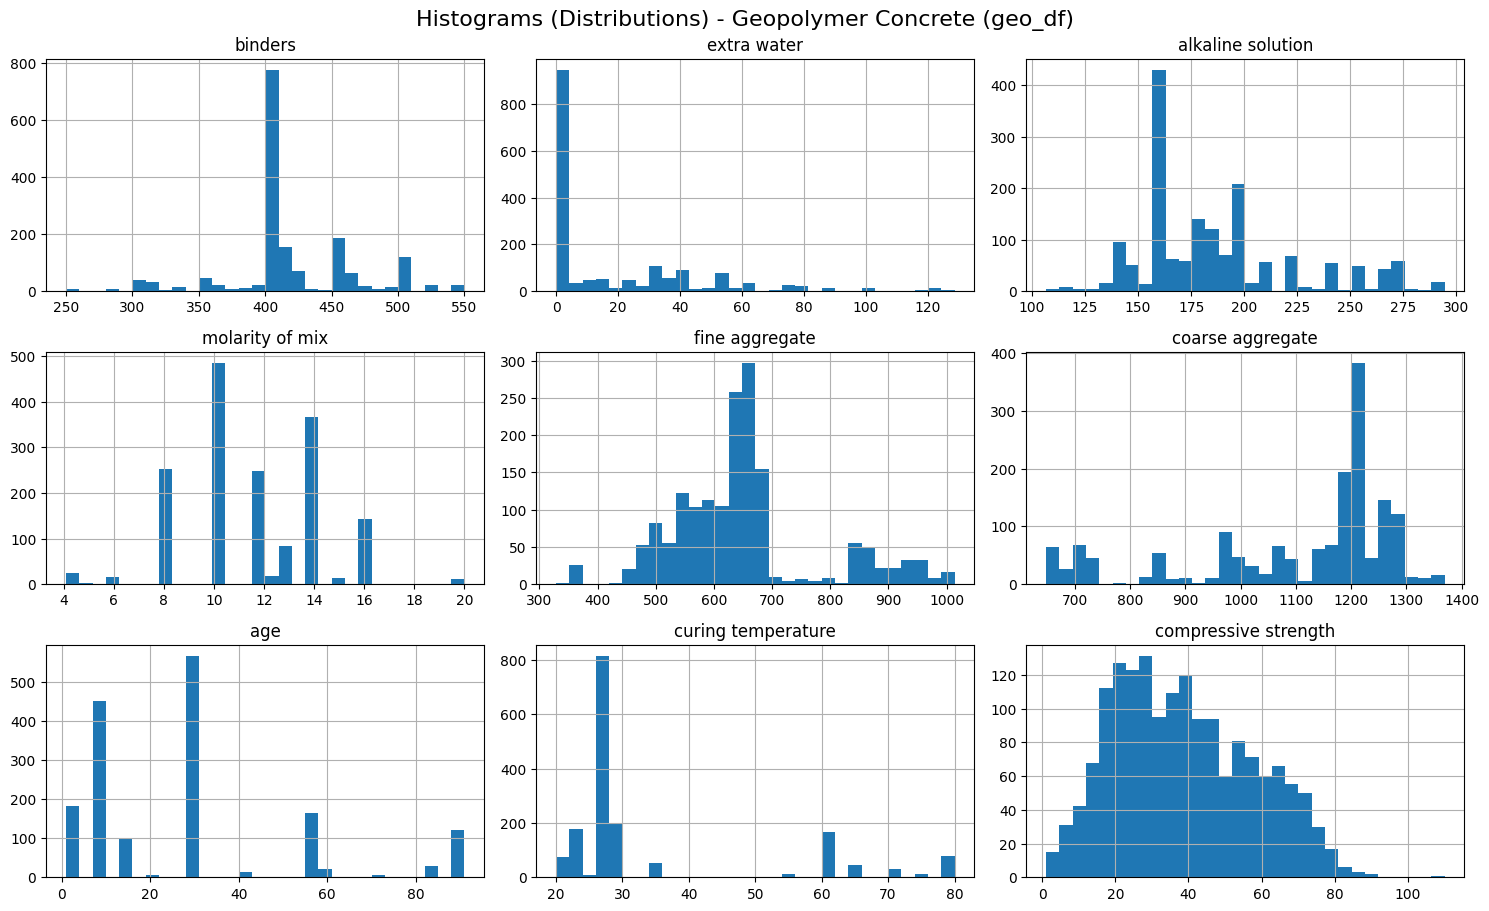

In [19]:
clean_geo_df = main_df.copy()
print("original number of rows: ", len(clean_geo_df))

numeric_geo = ['binder', 'extra water', 'alkaline solution', 'molarity of mix',
               'fine aggregate', 'coarse aggregate', 'age', 'curing temperature',
               'compressive strength', 'water']

clean_geo_df = clean_geo_df[clean_geo_df['age'] <= 175] 
clean_geo_df = clean_geo_df[clean_geo_df['extra water'] < 130]
clean_geo_df = clean_geo_df[(clean_geo_df['alkaline solution'] <= 300) & (clean_geo_df['alkaline solution'] > 100)]
clean_geo_df = clean_geo_df[clean_geo_df['molarity of mix'] <= 20]         
clean_geo_df = clean_geo_df[clean_geo_df['binders'] < 600]
clean_geo_df = clean_geo_df[clean_geo_df['compressive strength'] > 0]
clean_geo_df = clean_geo_df[clean_geo_df['curing temperature'] < 90]
clean_geo_df = clean_geo_df[clean_geo_df['coarse aggregate'] < 1400]
clean_geo_df = clean_geo_df[clean_geo_df['fine aggregate'] < 1100]

print(f"Geopolymer after cleaning: {len(clean_geo_df)} rows\n")

analyze_dataset(clean_geo_df, "Geopolymer Concrete (geo_df)")

In [20]:
main_df = clean_geo_df.copy()

EDA- Exploratory Data Analysis

In [21]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1662 entries, 0 to 2086
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   binders               1662 non-null   float64
 1   extra water           1662 non-null   float64
 2   alkaline solution     1662 non-null   float64
 3   molarity of mix       1662 non-null   float64
 4   fine aggregate        1662 non-null   float64
 5   coarse aggregate      1662 non-null   float64
 6   age                   1662 non-null   float64
 7   curing temperature    1662 non-null   float64
 8   compressive strength  1662 non-null   float64
dtypes: float64(9)
memory usage: 129.8 KB


In [22]:
main_df.describe().T

,count,mean,std,min,25%,50%,75%,max
binders,1662.0,415.861793,47.319133,250.00,400.00,400.0,450.00,550.00
extra water,1662.0,17.676054,26.338612,0.00,0.00,0.0,32.00,128.57
alkaline solution,1662.0,187.409057,36.642493,106.68,160.02,180.0,200.00,294.40
molarity of mix,1662.0,11.550181,2.748220,4.10,10.00,12.0,14.00,20.00
fine aggregate,1662.0,647.401029,125.185183,328.50,560.00,644.0,672.00,1013.63
coarse aggregate,1662.0,1100.151101,189.307767,647.80,995.75,1181.5,1220.35,1369.00
age,1662.0,27.644404,25.269086,1.00,7.00,28.0,28.00,91.00
curing temperature,1662.0,34.749097,16.785906,20.00,27.00,27.0,28.00,80.00
compressive strength,1662.0,38.701096,18.896069,1.10,23.50,36.8,53.16,110.00


In [23]:
main_df.nunique()

binders                   83
extra water               69
alkaline solution         84
molarity of mix           12
fine aggregate           150
coarse aggregate         161
age                       14
curing temperature        13
compressive strength    1249
dtype: int64

<Axes: >

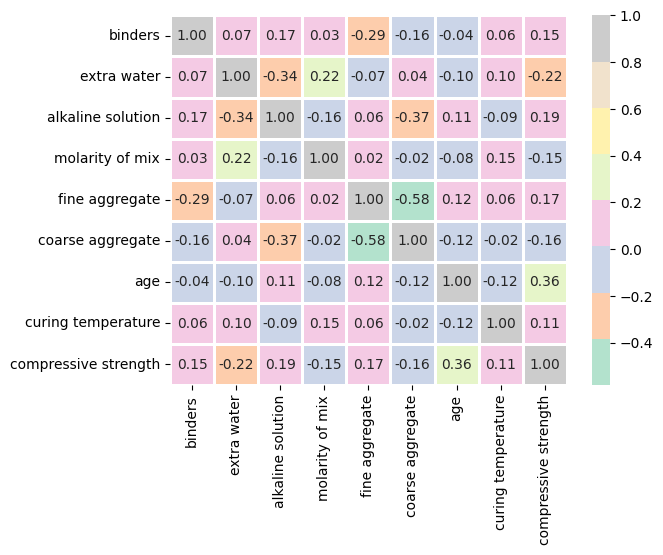

In [24]:
#multivariate analysis

import seaborn as sns

sns.heatmap(main_df.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

Dataset preparation

In [25]:
X = main_df.drop("compressive strength", axis=1)
y = main_df["compressive strength"]

X.shape,y.shape

((1662, 8), (1662,))

In [26]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% for validation+test combined
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Second split: Split the 30% into 50/50 (15% validation, 15% test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"\nSplit percentages:")
print(f"Train: {len(X_train) / len(X):.1%}")
print(f"Validation: {len(X_val) / len(X):.1%}")
print(f"Test: {len(X_test) / len(X):.1%}")

Train: (1163, 8)
Validation: (249, 8)
Test: (250, 8)

Split percentages:
Train: 70.0%
Validation: 15.0%
Test: 15.0%


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")

# Fit on training data only
X_train = scaler.fit_transform(X_train)
# Transform validation and test without refitting
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Model Training

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR #support vector regression
from sklearn.neighbors import KNeighborsRegressor 
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2 Score": r2_score(y_true, y_pred)
    }

In [30]:
import os
import joblib
import json 
from sklearn.model_selection import GridSearchCV
model_dir = "saved_models"

In [31]:
def load_or_train_model(model_name, train_logic_func):
    """
    Checks if a model exists. If it does, loads it. 
    If not, runs the provided training logic and saves the model.
    """
    directory = f'{model_dir}/geopolymer_dataset_regression_research_models'
    model_path = f'{directory}/{model_name}.pkl'
    model_config_path = f'{directory}/{model_name}.json'
    os.makedirs(directory, exist_ok=True)

    if os.path.exists(model_path):
        print(f"[{model_name}] Found saved model. Loading...")
        best_params = None
        if os.path.exists(model_config_path):
            with open(model_config_path, 'r') as f:
                best_params = json.load(f)
            print(f"[{model_name}] Loaded model parameters: {best_params}")
        return joblib.load(model_path), best_params
    else:
        print(f"[{model_name}] No saved model found. Training now...")
        
        # Execute the training function
        trained_model, trained_model_params = train_logic_func()
        
        # Save after training
        os.makedirs('saved_models', exist_ok=True)
        joblib.dump(trained_model, model_path)
        with open(model_config_path, 'w') as f:
            json.dump(trained_model_params, f, indent=4)
        print(f"[{model_name}] Training complete and model saved!\n")
        
        return trained_model, trained_model_params

In [32]:
#Linear Regression

def train_optuna_linear_regression():
    def objective(trial):
        # The only remaining valid parameter to tune
        fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
        
        lr = LinearRegression(fit_intercept=fit_intercept)
        
        # 5-Fold Cross Validation
        scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        return scores.mean() 

    study = optuna.create_study(direction="maximize", study_name="linear_regression_opt")
    study.optimize(objective, n_trials=5) # Only 5 trials needed for 2 boolean combinations

    print(f"Best Linear Regression params: {study.best_params}")
    
    # Retrain on the full training set with the best parameters
    best_lr = LinearRegression(**study.best_params)
    best_lr.fit(X_train, y_train)
    
    return best_lr, study.best_params

In [33]:
#catboost regressor
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
import optuna

def train_optuna_catboost():
    def objective(trial):
        params = {
            # Continuous ranges instead of discrete lists
            'iterations': trial.suggest_int('iterations', 100, 500, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'verbose': 0 # Keep logs quiet during trials
        }

        model = CatBoostRegressor(**params)
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction="maximize", study_name="catboost_opt")
    study.optimize(objective, n_trials=30) # 30 trials is a good sweet spot

    print(f"Best CatBoost params: {study.best_params}")
    
    # Retrain final model
    best_catboost = CatBoostRegressor(**study.best_params, verbose=0)
    best_catboost.fit(X_train, y_train)
    
    return best_catboost, study.best_params

In [34]:
#gradient boosting regressor
from sklearn.ensemble import GradientBoostingRegressor

def train_grid_gradient_boosting():
    gb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    gb_model = GradientBoostingRegressor()
    grid_search = GridSearchCV(estimator=gb_model, param_grid=gb_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_gb = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_gb, best_params

In [35]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
import optuna

def train_optuna_lgbm():
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'boosting_type': 'gbdt',
            'verbose': -1,
            'random_state': 42,
            # FIX: Restrict LightGBM to 1 thread per CV fold to prevent deadlock
            'n_jobs': 1 
        }

        model = LGBMRegressor(**params)
        
        # Keep n_jobs=-1 here so it runs the 5 folds in parallel
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction="maximize", study_name="lgbm_opt")
    study.optimize(objective, n_trials=30)

    print(f"Best LGBM params: {study.best_params}")
    
    # Retrain final model (You can let this use all cores since CV is done)
    best_lgbm = LGBMRegressor(**study.best_params, n_jobs=-1)
    best_lgbm.fit(X_train, y_train)
    
    return best_lgbm, study.best_params

In [36]:
#Decision Tree Regressor

def train_grid_decision_tree():
    dt_params = {
        'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
        'splitter': ['best', 'random'],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    dt = DecisionTreeRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=dt, param_grid=dt_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_dt = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_dt, best_params

In [37]:
#Random Forest

def train_grid_random_forest():
    rf_params = {
        'n_estimators': [100, 200, 300],
        'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=rf_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_rf, best_params

In [38]:
#Support Vector Regression

def train_grid_svr():
    svr_params = {
        'kernel': ['linear', 'rbf', 'poly'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    }

    svr = SVR()
    grid_search = GridSearchCV(estimator=svr, param_grid=svr_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_svr = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_svr, best_params

In [39]:
#K-Nearest Neighbors

def train_grid_knn():
    knn_params = {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }

    knn = KNeighborsRegressor()
    grid_search = GridSearchCV(estimator=knn, param_grid=knn_params, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_knn = grid_search.best_estimator_
    best_params = grid_search.best_params_
    return best_knn, best_params

In [40]:
#XGBoost Regressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import optuna
import gc # Import Python's garbage collector

def train_optuna_xgboost():
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 7), 
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_state': 42,
            
            # --- THE MEMORY SAVERS ---
            'tree_method': 'hist',
            'n_jobs': -1           # Safe to use all cores because we are only training 1 model at a time
        }

        model = XGBRegressor(**params)
        
        # OOM FIX: n_jobs=1 prevents holding 5 heavy models in memory simultaneously
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=1)
        
        # Force Python to clear the RAM immediately after the fold finishes
        del model
        gc.collect() 
        
        return scores.mean()

    study = optuna.create_study(direction="maximize", study_name="xgb_opt")
    study.optimize(objective, n_trials=20) 

    print(f"Best XGBoost params: {study.best_params}")
    
    # Retrain final model
    best_params = study.best_params
    best_params['tree_method'] = 'hist' # Ensure final model uses the lightweight method
    
    best_xgb = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    best_xgb.fit(X_train, y_train)
    
    return best_xgb, study.best_params

In [41]:
#ann 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import copy

# Set device to utilize GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Define the dynamic PyTorch Model
class DynamicANN(nn.Module):
    def __init__(self, trial, input_dim):
        super(DynamicANN, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Tune the number of hidden layers (1 to 3)
        num_layers = trial.suggest_int('num_layers', 1, 3)
        
        # Tune activation function globally for the network
        activation_name = trial.suggest_categorical('activation', ['relu', 'tanh'])
        activation_layer = nn.ReLU() if activation_name == 'relu' else nn.Tanh()
        
        in_features = input_dim
        
        for i in range(num_layers):
            # Tune the number of neurons in each layer
            out_features = trial.suggest_int(f'units_{i}', 32, 256, step=32)
            self.layers.append(nn.Linear(in_features, out_features))
            self.layers.append(activation_layer)
            
            # Add Dropout to prevent overfitting
            dropout_rate = trial.suggest_float(f'dropout_{i}', 0.1, 0.5, step=0.1)
            self.layers.append(nn.Dropout(dropout_rate))
            
            in_features = out_features
            
        # Output layer for regression (1 node, linear activation)
        self.output = nn.Linear(in_features, 1)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.output(x)

# 2. Define the Optuna Objective Function
def objective(trial, train_loader, val_loader, input_dim):
    # Instantiate the model
    model = DynamicANN(trial, input_dim).to(device)
    
    # Tune the learning rate
    lr = trial.suggest_categorical('learning_rate', [1e-2, 1e-3, 1e-4])
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Early stopping variables
    patience = 10
    patience_counter = 0
    best_val_loss = float('inf')
    best_model_weights = None
    
    epochs = 100
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                preds = model(batch_X)
                # Multiply by batch size to calculate accurate average later
                val_loss += criterion(preds, batch_y).item() * batch_X.size(0)
                
        val_loss /= len(val_loader.dataset)
        
        # Report intermediate values for Optuna's Pruner
        trial.report(val_loss, epoch)
        
        # Stop unpromising trials early (Optuna feature, faster than Keras)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
        # --- Early Stopping Logic ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            break # Trigger early stopping
            
    # Save the best weights found during this specific trial into the trial object
    trial.set_user_attr("best_weights", best_model_weights)
    
    return best_val_loss

# 3. Main execution function
def tune_pytorch_ann():
    # Convert numpy arrays to PyTorch Tensors
    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)
    X_val_np = np.array(X_val)
    y_val_np = np.array(y_val)

    X_train_t = torch.FloatTensor(X_train_np)
    y_train_t = torch.FloatTensor(y_train_np).view(-1, 1) # Ensure 2D shape
    X_val_t = torch.FloatTensor(X_val_np)
    y_val_t = torch.FloatTensor(y_val_np).view(-1, 1)
    
    # Create DataLoaders
    batch_size = 32
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    input_dim = X_train.shape[1]
    
    # 4. Set up the Optuna Study
    study = optuna.create_study(
        study_name="ann_optimization",
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10) # Pruning mechanism
    )
    
    # Run the optimization
    study.optimize(
        lambda trial: objective(trial, train_loader, val_loader, input_dim), 
        n_trials=30
    )
    
    # Retrieve the best hyperparameters
    best_trial = study.best_trial
    best_hps = best_trial.params
    
    # Reconstruct the best model using the saved weights
    best_keras_model = DynamicANN(best_trial, input_dim)
    best_keras_model.load_state_dict(best_trial.user_attrs["best_weights"])
    
    return best_keras_model, best_hps

# Execution example:
# best_model, best_params = tune_pytorch_ann(X_train, y_train, X_val, y_val)
    

Using device: cuda


In [42]:
import os
import json
import torch
import torch.nn as nn

# 1. Create a dedicated Loader Class (Does not affect your original DynamicANN)
class InferenceANN(nn.Module):
    """
    A standalone class used STRICTLY for reconstructing the PyTorch model 
    from saved JSON parameters without needing Optuna.
    """
    def __init__(self, input_dim, num_layers, units, dropouts, activation_name):
        super(InferenceANN, self).__init__()
        
        self.layers = nn.ModuleList()
        activation_layer = nn.ReLU() if activation_name == 'relu' else nn.Tanh()
        
        in_features = input_dim
        
        for i in range(num_layers):
            out_features = units[i]
            self.layers.append(nn.Linear(in_features, out_features))
            self.layers.append(activation_layer)
            
            # Add Dropout
            self.layers.append(nn.Dropout(p=dropouts[i]))
            
            in_features = out_features
            
        # Output layer for regression
        self.output = nn.Linear(in_features, 1)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.output(x)

# 2. Update the load function to use the new InferenceANN class
def load_or_train_pytorch_model(model_name, train_logic_func, input_dim):
    """
    Dedicated PyTorch save/load flow utilizing state_dicts and handling device mapping.
    """
    model_dir = 'saved_models'
    directory = f'{model_dir}/geopolymer_dataset_regression_research_models'
    
    model_path = f'{directory}/{model_name}.pth' 
    model_config_path = f'{directory}/{model_name}.json'
    
    os.makedirs(directory, exist_ok=True)

    if os.path.exists(model_path) and os.path.exists(model_config_path):
        print(f"[{model_name}] Found saved PyTorch weights. Loading...")
        
        with open(model_config_path, 'r') as f:
            best_params = json.load(f)
            
        print(f"[{model_name}] Loaded model parameters: {best_params}")
        
        # Parse the saved parameters
        num_layers = best_params['num_layers']
        activation = best_params['activation']
        units = [best_params[f'units_{i}'] for i in range(num_layers)]
        dropouts = [best_params[f'dropout_{i}'] for i in range(num_layers)]
        
        # USE THE NEW CLASS HERE:
        loaded_model = InferenceANN(input_dim, num_layers, units, dropouts, activation)
        
        loaded_model.load_state_dict(torch.load(model_path, map_location=device))
        loaded_model.to(device)
        loaded_model.eval() 
        
        return loaded_model, best_params

    else:
        print(f"[{model_name}] No saved model found. Training now...")
        
        # Executes your original Optuna code with the original DynamicANN
        trained_model, trained_model_params = train_logic_func()
        
        torch.save(trained_model.state_dict(), model_path)
        
        with open(model_config_path, 'w') as f:
            json.dump(trained_model_params, f, indent=4)
            
        print(f"[{model_name}] Training complete and PyTorch weights saved!\n")
        
        return trained_model, trained_model_params

In [43]:
#linear regression
best_lr, best_lr_params = load_or_train_model("linear_regression", train_optuna_linear_regression)

[linear_regression] Found saved model. Loading...
[linear_regression] Loaded model parameters: {'fit_intercept': True}


In [44]:
#catboost regressor
best_catboost, best_catboost_params = load_or_train_model("catboost_regressor", train_optuna_catboost)

[catboost_regressor] Found saved model. Loading...
[catboost_regressor] Loaded model parameters: {'iterations': 450, 'learning_rate': 0.11250573941935278, 'depth': 6, 'l2_leaf_reg': 1.0598587158386932}


In [ ]:
#lgbm regressor
best_lgbm, best_lgbm_params = load_or_train_model("lgbm_regressor", train_optuna_lgbm)

[lgbm_regressor] Found saved model. Loading...
[lgbm_regressor] Loaded model parameters: {'n_estimators': 280, 'learning_rate': 0.10499274451357209, 'num_leaves': 21}


In [46]:
#gradient boosting regressor
best_gb, best_gb_params = load_or_train_model("gradient_boosting_regressor", train_grid_gradient_boosting)

[gradient_boosting_regressor] Found saved model. Loading...
[gradient_boosting_regressor] Loaded model parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [47]:
#decision tree regressor
best_dt, best_dt_params = load_or_train_model("decision_tree_regressor", train_grid_decision_tree)

[decision_tree_regressor] Found saved model. Loading...
[decision_tree_regressor] Loaded model parameters: {'criterion': 'poisson', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'random'}


In [48]:
#svr
best_svr, best_svr_params = load_or_train_model("svr", train_grid_svr)

[svr] Found saved model. Loading...
[svr] Loaded model parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [49]:
#knn
best_knn, best_knn_params = load_or_train_model("knn", train_grid_knn)

[knn] Found saved model. Loading...
[knn] Loaded model parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [50]:
#xgboost
best_xgb, best_xgb_params = load_or_train_model("xgboost_regressor", train_optuna_xgboost)

[xgboost_regressor] Found saved model. Loading...
[xgboost_regressor] Loaded model parameters: {'n_estimators': 300, 'learning_rate': 0.07785638163122045, 'max_depth': 5, 'subsample': 0.8519883866889425}


In [51]:
#random forest
best_rf, best_rf_params = load_or_train_model("random_forest_regressor", train_grid_random_forest)

[random_forest_regressor] Found saved model. Loading...
[random_forest_regressor] Loaded model parameters: {'criterion': 'absolute_error', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [52]:
#train or load ann
best_ann_model, best_ann_params = load_or_train_pytorch_model("ann_model", tune_pytorch_ann, input_dim=X_train.shape[1])

[ann_model] Found saved PyTorch weights. Loading...
[ann_model] Loaded model parameters: {'num_layers': 2, 'activation': 'tanh', 'units_0': 192, 'dropout_0': 0.2, 'units_1': 224, 'dropout_1': 0.2, 'learning_rate': 0.01}


In [ ]:
# evaluation of the loaded models

lr_eval = evaluate_model(y_test, best_lr.predict(X_test))
catboost_eval = evaluate_model(y_test, best_catboost.predict(X_test))
lgbm_eval = evaluate_model(y_test, best_lgbm.predict(X_test))
gb_eval = evaluate_model(y_test, best_gb.predict(X_test))
dt_eval = evaluate_model(y_test, best_dt.predict(X_test))
rf_eval = evaluate_model(y_test, best_rf.predict(X_test))
svr_eval = evaluate_model(y_test, best_svr.predict(X_test))
knn_eval = evaluate_model(y_test, best_knn.predict(X_test))
xgb_eval = evaluate_model(y_test, best_xgb.predict(X_test))

X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32).to(device)
ann_model_eval = evaluate_model(y_test, best_ann_model(X_test_tensor).cpu().detach().numpy().squeeze())

/home/mukundvinayak/machine-learning/advanced-concrete-mixing-analysis/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/mukundvinayak/machine-learning/advanced-concrete-mixing-analysis/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(
/home/mukundvinayak/machine-learning/advanced-concrete-mixing-analysis/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/mukundvinayak/machine-learning/advanced-concrete-mixing-analysis/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/

In [54]:
# Collecting all evaluations in a dictionary for easy comparison

all_evaluations = {
    "Linear Regression": lr_eval,
    "CatBoost Regressor": catboost_eval,
    "LightGBM Regressor": lgbm_eval,
    "Gradient Boosting Regressor": gb_eval,
    "Decision Tree Regressor": dt_eval,
    "Random Forest Regressor": rf_eval,
    "Support Vector Regressor": svr_eval,
    "K-Nearest Neighbors": knn_eval,
    "XGBoost Regressor": xgb_eval,
    "ANN (PyTorch)": ann_model_eval
}

Visualization

In [55]:
import matplotlib.pyplot as plt

In [56]:
all_evaluations

{'Linear Regression': {'RMSE': np.float64(15.701071723004471),
  'MSE': 246.5236532509306,
  'MAE': 13.213196679613903,
  'R2 Score': 0.3228993003131735},
 'CatBoost Regressor': {'RMSE': np.float64(8.319278531654724),
  'MSE': 69.21039528725119,
  'MAE': 5.177631887222591,
  'R2 Score': 0.8099070557464947},
 'LightGBM Regressor': {'RMSE': np.float64(8.40977180906348),
  'MSE': 70.72426188051884,
  'MAE': 5.5269952561142945,
  'R2 Score': 0.8057490769237053},
 'Gradient Boosting Regressor': {'RMSE': np.float64(8.770395479163174),
  'MSE': 76.91983686092584,
  'MAE': 5.5160002831475365,
  'R2 Score': 0.7887323399945079},
 'Decision Tree Regressor': {'RMSE': np.float64(10.129543695069593),
  'MSE': 102.60765547032413,
  'MAE': 6.658597536752137,
  'R2 Score': 0.7181782989340029},
 'Random Forest Regressor': {'RMSE': np.float64(8.88506149583354),
  'MSE': 78.94431778474373,
  'MAE': 5.791558604299995,
  'R2 Score': 0.7831719102672052},
 'Support Vector Regressor': {'RMSE': np.float64(11.55

/tmp/ipykernel_16512/870642787.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')
/tmp/ipykernel_16512/870642787.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')
/tmp/ipykernel_16512/870642787.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')
/tmp/ipykernel_16512/870642787.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')


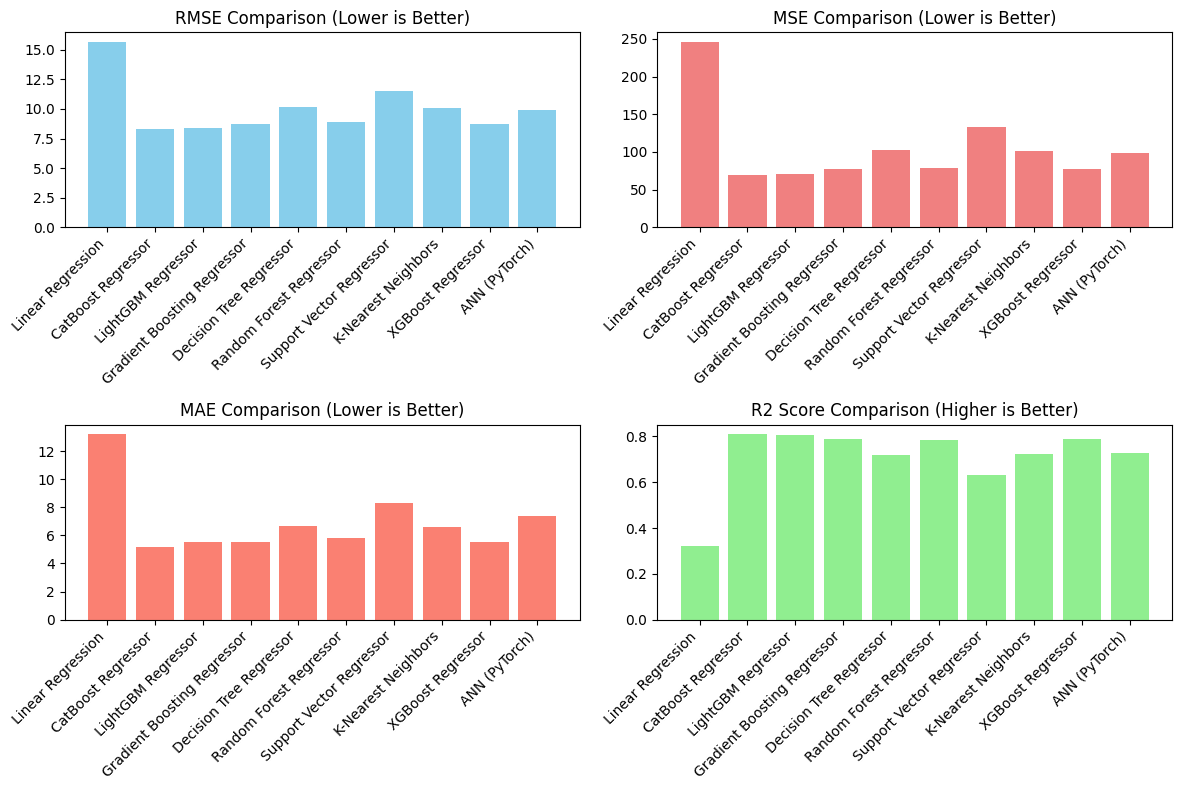

In [57]:
# Combined Comparison: lower, the better

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# RMSE Comparison
rmse_values = [evals['RMSE'] for evals in all_evaluations.values()]
axes[0, 0].bar(all_evaluations.keys(), rmse_values, color='skyblue')
axes[0, 0].set_title('RMSE Comparison (Lower is Better)')
axes[0, 0].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')

# MSE Comparison
mse_values = [evals['MSE'] for evals in all_evaluations.values()]
axes[0, 1].bar(all_evaluations.keys(), mse_values, color='lightcoral')
axes[0, 1].set_title('MSE Comparison (Lower is Better)')
axes[0, 1].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')

# MAE Comparison
mae_values = [evals['MAE'] for evals in all_evaluations.values()]
axes[1, 0].bar(all_evaluations.keys(), mae_values, color='salmon')
axes[1, 0].set_title('MAE Comparison (Lower is Better)')
axes[1, 0].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')

# R2 Score Comparison
r2_values = [evals['R2 Score'] for evals in all_evaluations.values()]
axes[1, 1].bar(all_evaluations.keys(), r2_values, color='lightgreen')
axes[1, 1].set_title('R2 Score Comparison (Higher is Better)')
axes[1, 1].set_xticklabels(all_evaluations.keys(), rotation=45, ha='right')



plt.tight_layout()
plt.show()

Linear regression is the worst in case of performance, as observed... the complex relationship between data is not efficiently captured here. further analysis will be rejected.

Artificial neural networks and the support vector regression models show similar performance, with ANN slightly outperforming SVR. This suggests that the non-linear relationships in the data are better captured by ANN, but SVR also provides a reasonable fit. But both models still struggle to capture the full complexity of the data, indicating that further tuning or more complex models may be needed for optimal performance. This is expected.

the k-nearest neighbors regression model performs better than linear regression, but still struggles to capture the underlying patterns in the data, leading to suboptimal performance.

decision tree regression shows the best performance among the models tested, indicating that it is better able to capture the complex relationships in the data. However, it may still be prone to overfitting, so further validation and tuning may be necessary to ensure its generalizability.

The tree models (except decision tree regression) show the best performance among the models tested, indicating that they are better able to capture the complex relationships in the data. However, they may still be prone to overfitting, so further validation and tuning may be necessary to ensure their generalizability. All the decision tree-based models used are Catboost, Lightgbm, xgboost, gradient boosting, and random forest regression. These models are known for their ability to capture complex relationships in data and often perform well on structured datasets like this one. However, they can be prone to overfitting if not properly tuned, so it's important to validate their performance on unseen data and consider techniques like cross-validation or regularization to improve their generalizability. Further analysis will be made for these tree models only, as they show the best performance among the models tested.


Index(['binders', 'extra water', 'alkaline solution', 'molarity of mix',
       'fine aggregate', 'coarse aggregate', 'age', 'curing temperature'],
      dtype='object')
[0.12525978 0.05067317 0.10679001 0.05605146 0.15443279 0.1946017
 0.17484694 0.13734416]


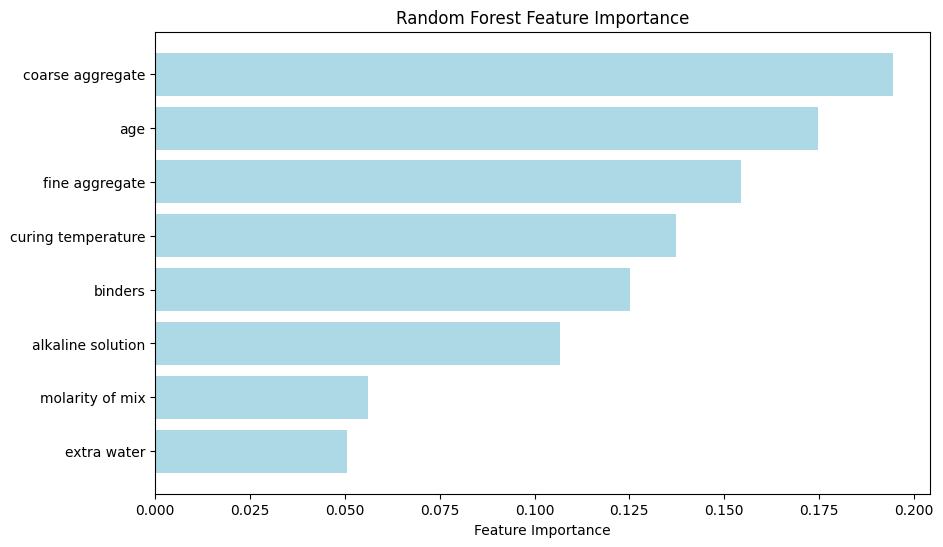

In [58]:
#feature importance of the random forest regression model.

print(main_df.columns[:-1])
print(best_rf.feature_importances_)

rf_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_rf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(rf_importances['feature'], rf_importances['importance'], color='lightblue')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

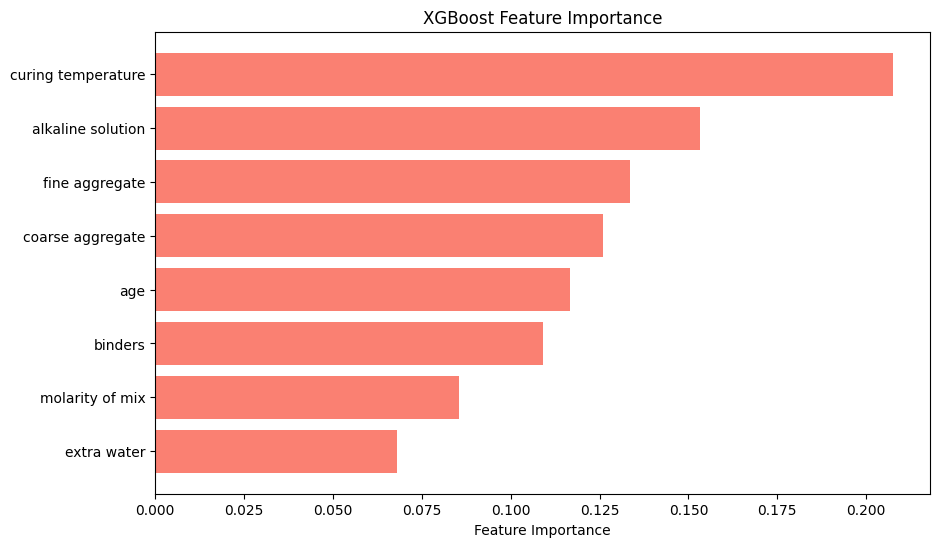

In [59]:
#Feature importance of the XGBoost regression model.

xgb_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(xgb_importances['feature'], xgb_importances['importance'], color='salmon')
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

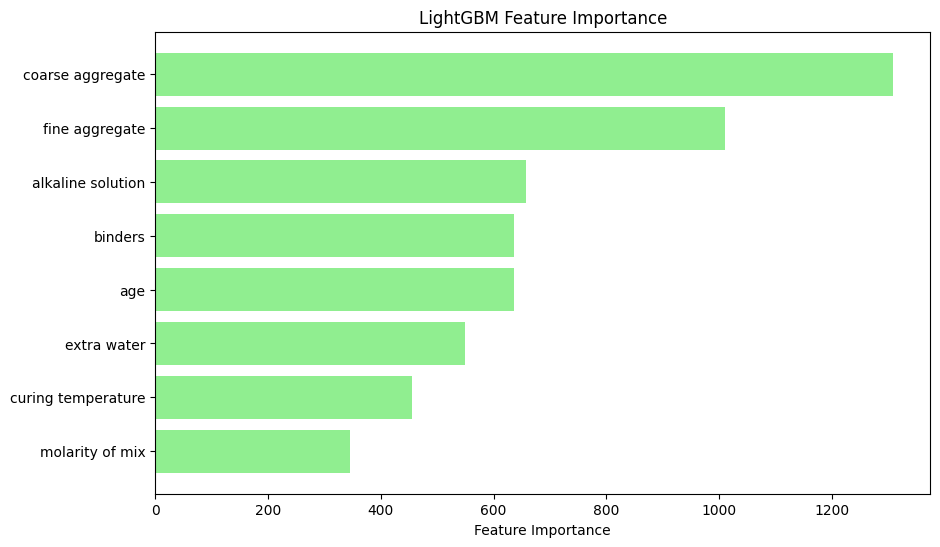

In [60]:
# feature importance of the lightgbm regression model.

lgbm_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_lgbm.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(lgbm_importances['feature'], lgbm_importances['importance'], color='lightgreen')
plt.xlabel('Feature Importance')
plt.title('LightGBM Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

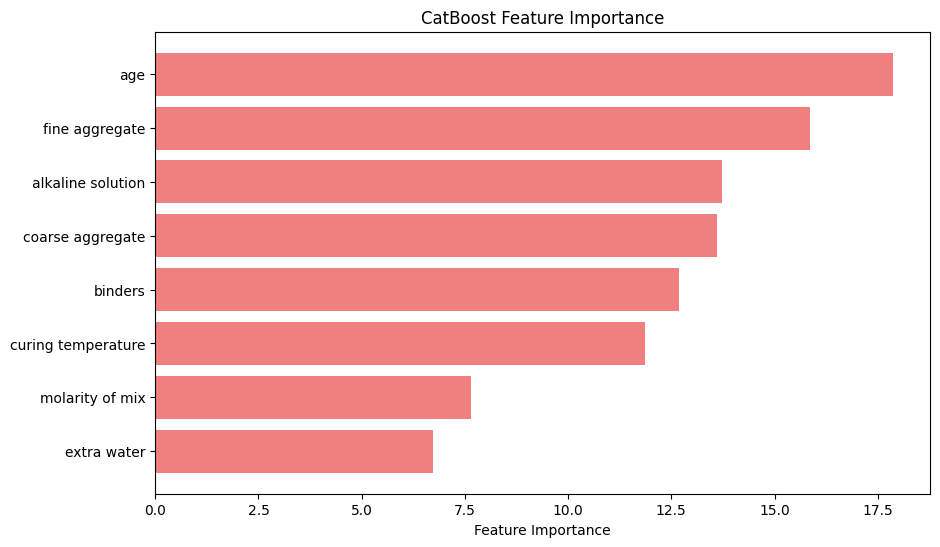

In [61]:
#feature importance of the catboost regression model.

catboost_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_catboost.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(catboost_importances['feature'], catboost_importances['importance'], color='lightcoral')
plt.xlabel('Feature Importance')
plt.title('CatBoost Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

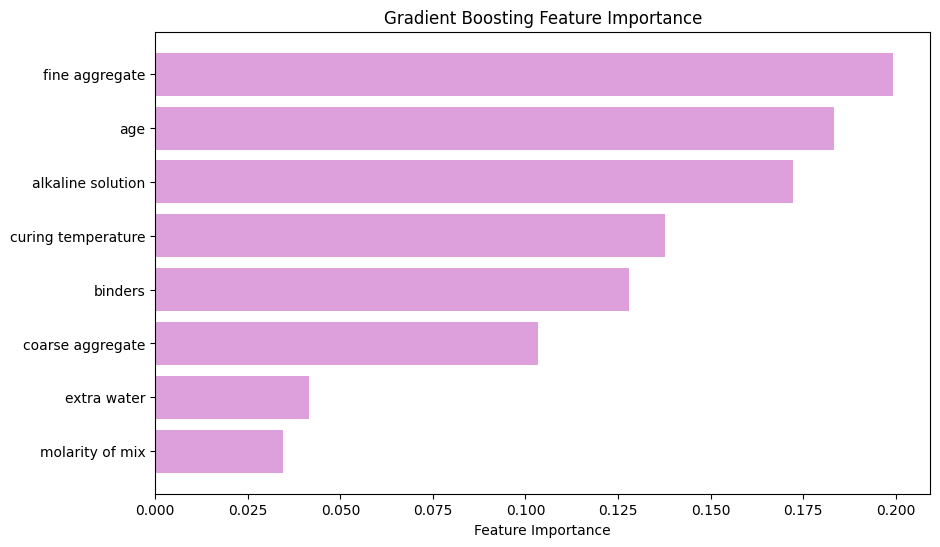

In [62]:
# feature importance of the gradient boosting regression model.

gb_importances = pd.DataFrame({
    'feature': main_df.columns[:-1],
    'importance': best_gb.feature_importances_
}).sort_values(by='importance', ascending=False)    

plt.figure(figsize=(10, 6))
plt.barh(gb_importances['feature'], gb_importances['importance'], color='plum')
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

applying the SHAP values to the tree models to understand the feature importance and how each feature contributes to the predictions made by the models. This will help in interpreting the results and identifying which features have the most significant impact on the target variable, which in this case is likely the compressive strength of the material being studied. By analyzing the SHAP values, we can gain insights into the relationships between the features and the target variable, and potentially identify areas for further investigation or improvement in the model's performance.

In [63]:
import shap

PermutationExplainer explainer: 251it [01:03,  3.30it/s]                         


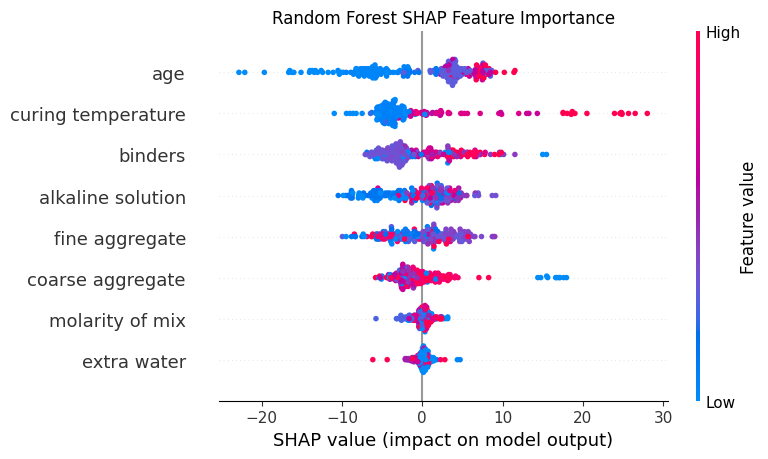

<Figure size 1000x600 with 0 Axes>

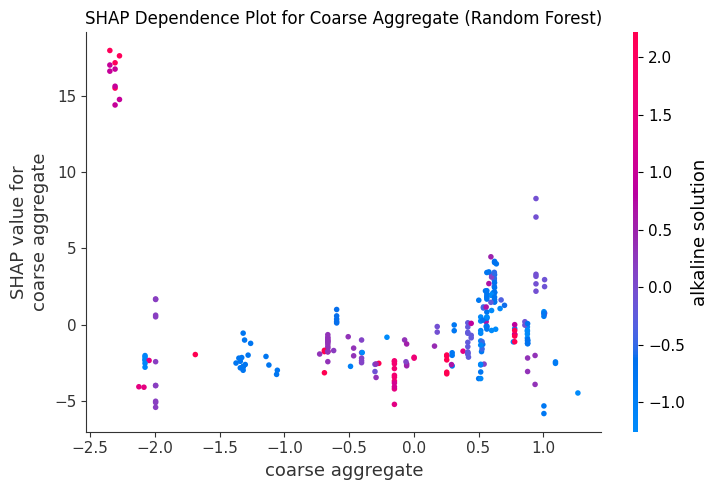

<Figure size 1000x600 with 0 Axes>

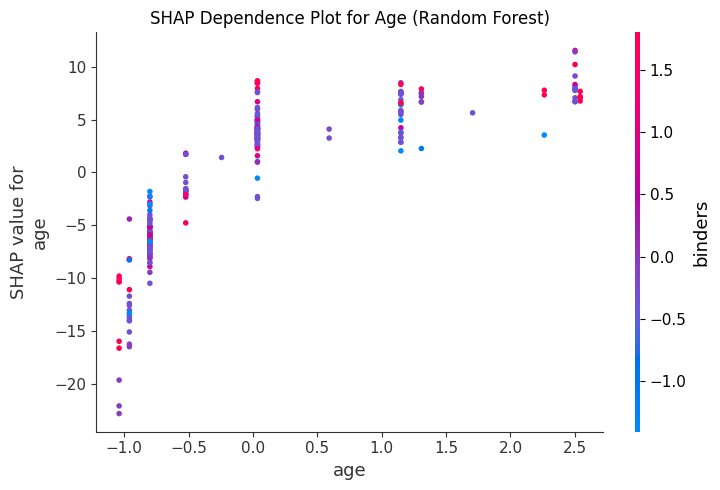

In [86]:
# shap analysis for random forest regression model

explainer_rf = shap.PermutationExplainer(best_rf.predict, X_test)
shap_values_rf = explainer_rf.shap_values(X_test)

shap.summary_plot(shap_values_rf, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("Random Forest SHAP Feature Importance")
plt.tight_layout()
plt.show()

# coarse aggregate and age are the most important features for the random forest regression model according to the shap analysis.
plt.figure(figsize=(10, 6))
shap.dependence_plot("coarse aggregate", shap_values_rf, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Coarse Aggregate (Random Forest)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("age", shap_values_rf, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Age (Random Forest)")
plt.tight_layout()
plt.show()

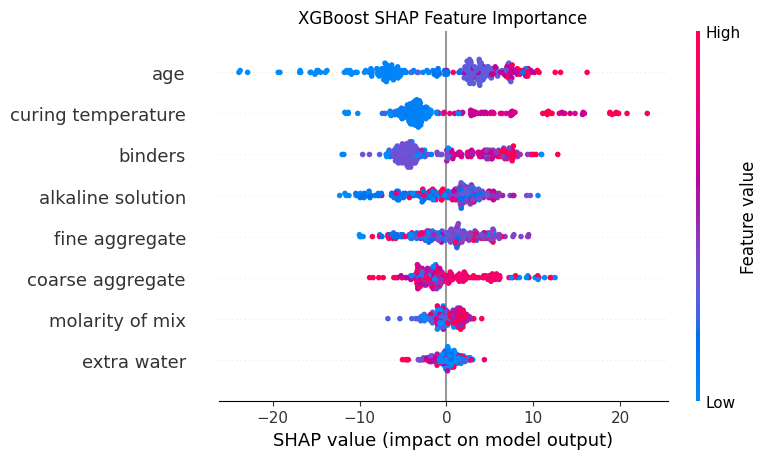

<Figure size 1000x600 with 0 Axes>

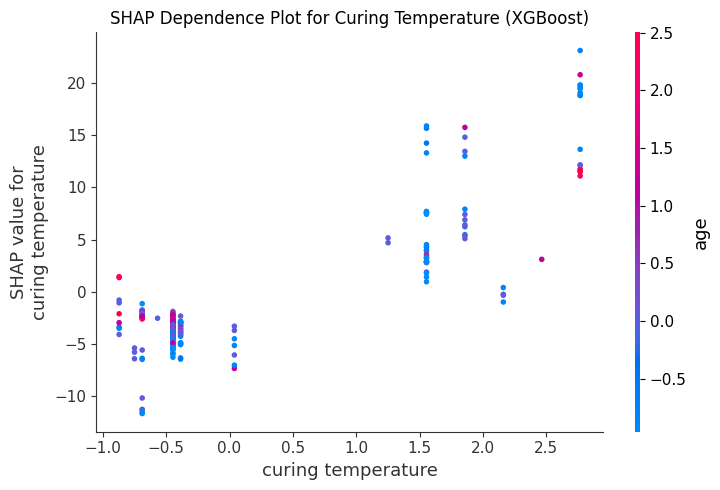

<Figure size 1000x600 with 0 Axes>

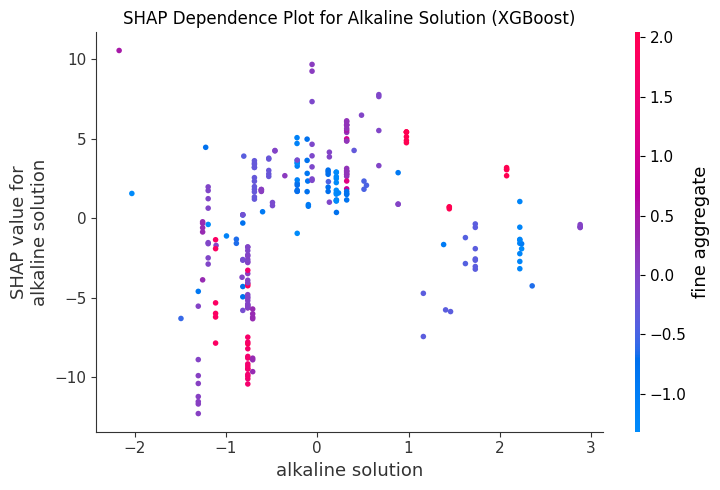

In [87]:
# shap analysis for the Xgboost regression model

explainer_xgb = shap.PermutationExplainer(best_xgb.predict, X_test)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("XGBoost SHAP Feature Importance")
plt.tight_layout()
plt.show()

# curing temperature and alkaline solution are the most important features for the XGBoost regression model according to the shap analysis.
plt.figure(figsize=(10, 6))
shap.dependence_plot("curing temperature", shap_values_xgb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Curing Temperature (XGBoost)")
plt.tight_layout()
plt.show()  

plt.figure(figsize=(10, 6))
shap.dependence_plot("alkaline solution", shap_values_xgb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Alkaline Solution (XGBoost)")
plt.tight_layout()  
plt.show()

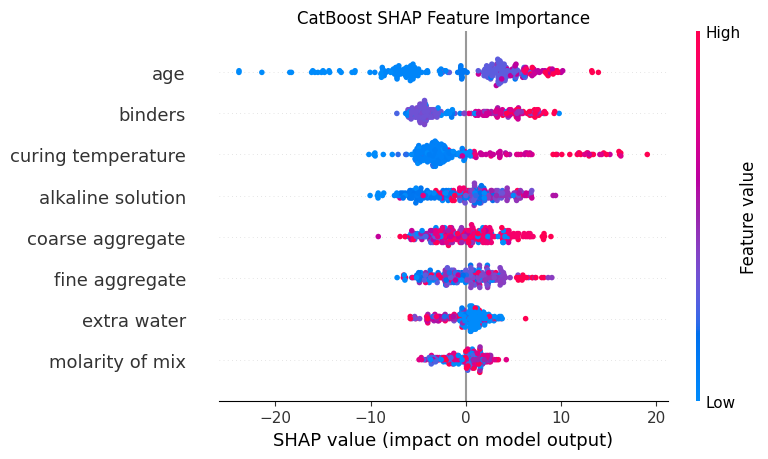

<Figure size 1000x600 with 0 Axes>

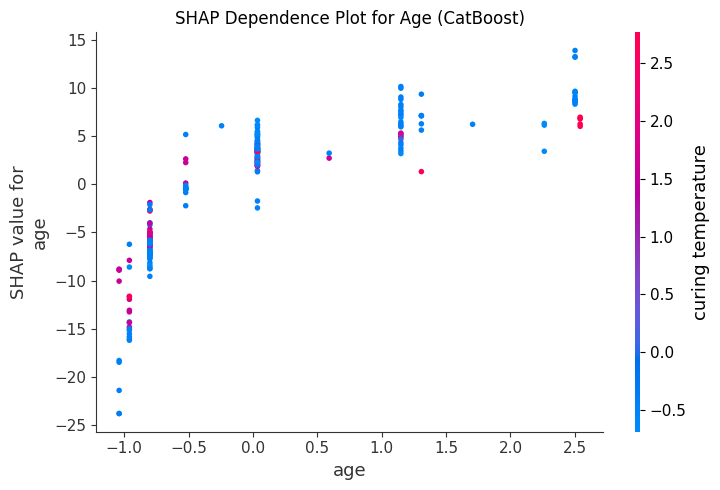

<Figure size 1000x600 with 0 Axes>

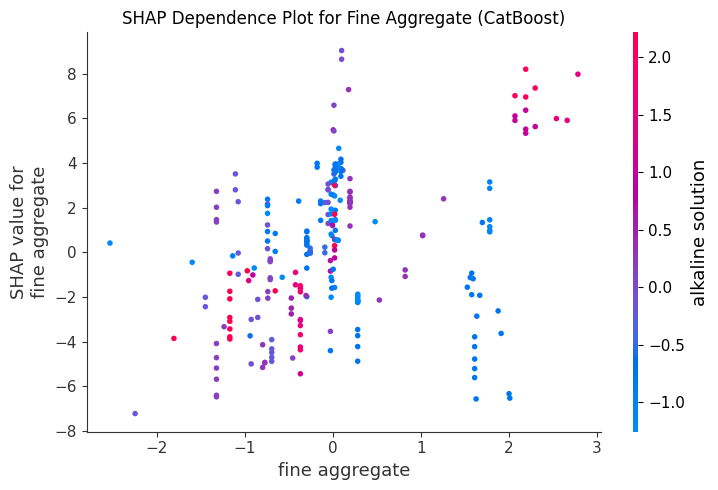

In [88]:
#feature importance of the catboost regression model. age and fine aggregate are the most important features for the catboost regression model according to the shap analysis.

explainer_catboost = shap.PermutationExplainer(best_catboost.predict, X_test)
shap_values_catboost = explainer_catboost.shap_values(X_test)
shap.summary_plot(shap_values_catboost, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("CatBoost SHAP Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("age", shap_values_catboost, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Age (CatBoost)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("fine aggregate", shap_values_catboost, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Fine Aggregate (CatBoost)")
plt.tight_layout()
plt.show()


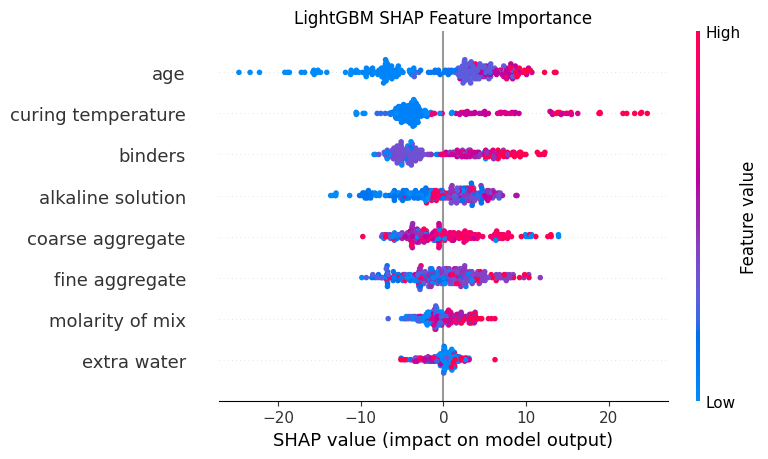

<Figure size 1000x600 with 0 Axes>

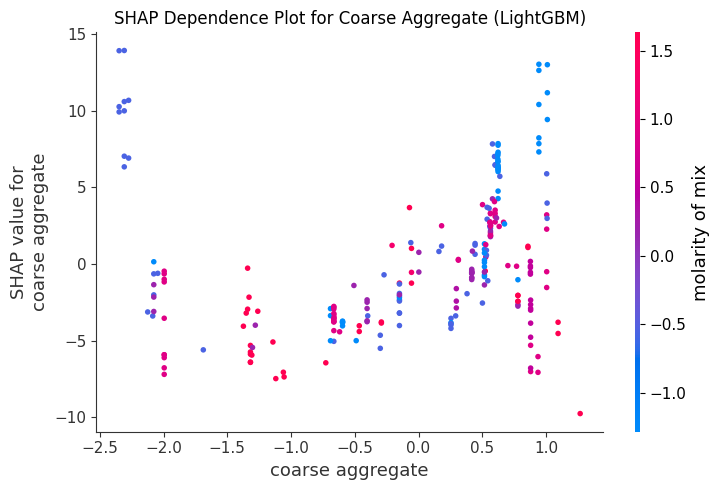

<Figure size 1000x600 with 0 Axes>

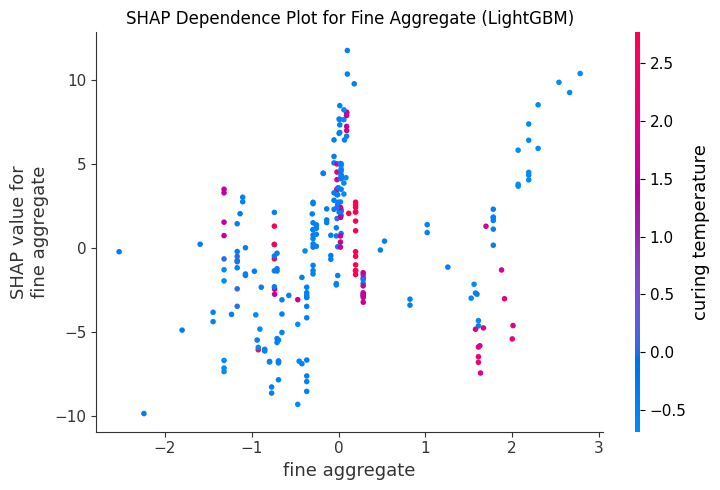

In [89]:
#feature importance of the lightgbm regression model.

#coarse aggregate and fine aggregate are the most important features for the lightgbm regression model according to the shap analysis.

explainer_lgbm = shap.PermutationExplainer(best_lgbm.predict, X_test)
shap_values_lgbm = explainer_lgbm.shap_values(X_test)
shap.summary_plot(shap_values_lgbm, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("LightGBM SHAP Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("coarse aggregate", shap_values_lgbm, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Coarse Aggregate (LightGBM)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("fine aggregate", shap_values_lgbm, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Fine Aggregate (LightGBM)")
plt.tight_layout()
plt.show()


PermutationExplainer explainer: 251it [00:13,  5.45it/s]                         


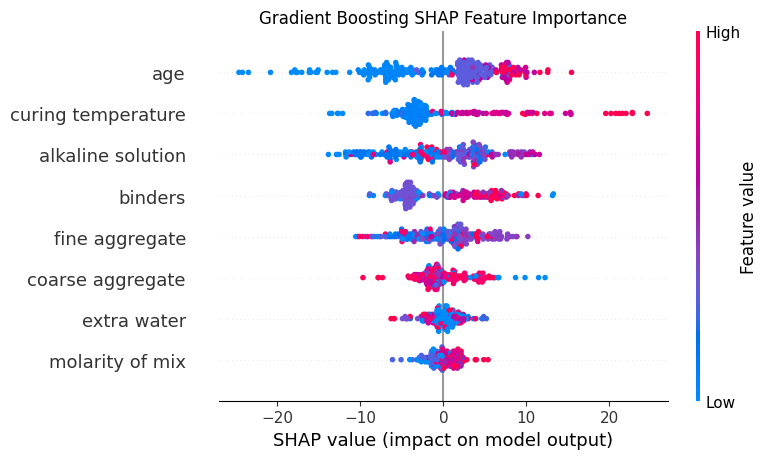

<Figure size 1000x600 with 0 Axes>

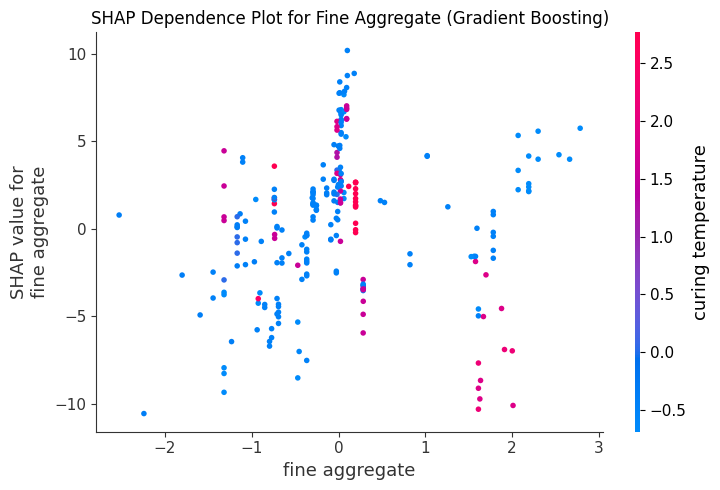

<Figure size 1000x600 with 0 Axes>

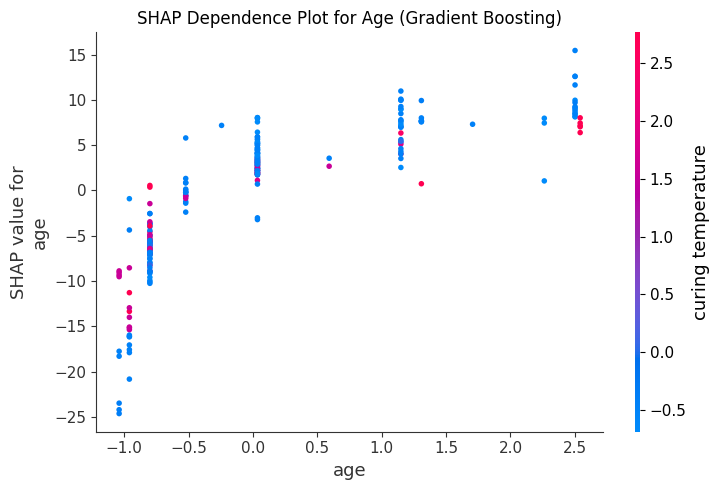

In [90]:
# shap values for the gradient boosting regression model

# fine aggregate and age are the most important features for the gradient boosting regression model according to the shap analysis.

explainer_gb = shap.PermutationExplainer(best_gb.predict, X_test)
shap_values_gb = explainer_gb.shap_values(X_test)
shap.summary_plot(shap_values_gb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("Gradient Boosting SHAP Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("fine aggregate", shap_values_gb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Fine Aggregate (Gradient Boosting)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot("age", shap_values_gb, X_test, feature_names=main_df.columns[:-1], show=False)
plt.title("SHAP Dependence Plot for Age (Gradient Boosting)")
plt.tight_layout()
plt.show()


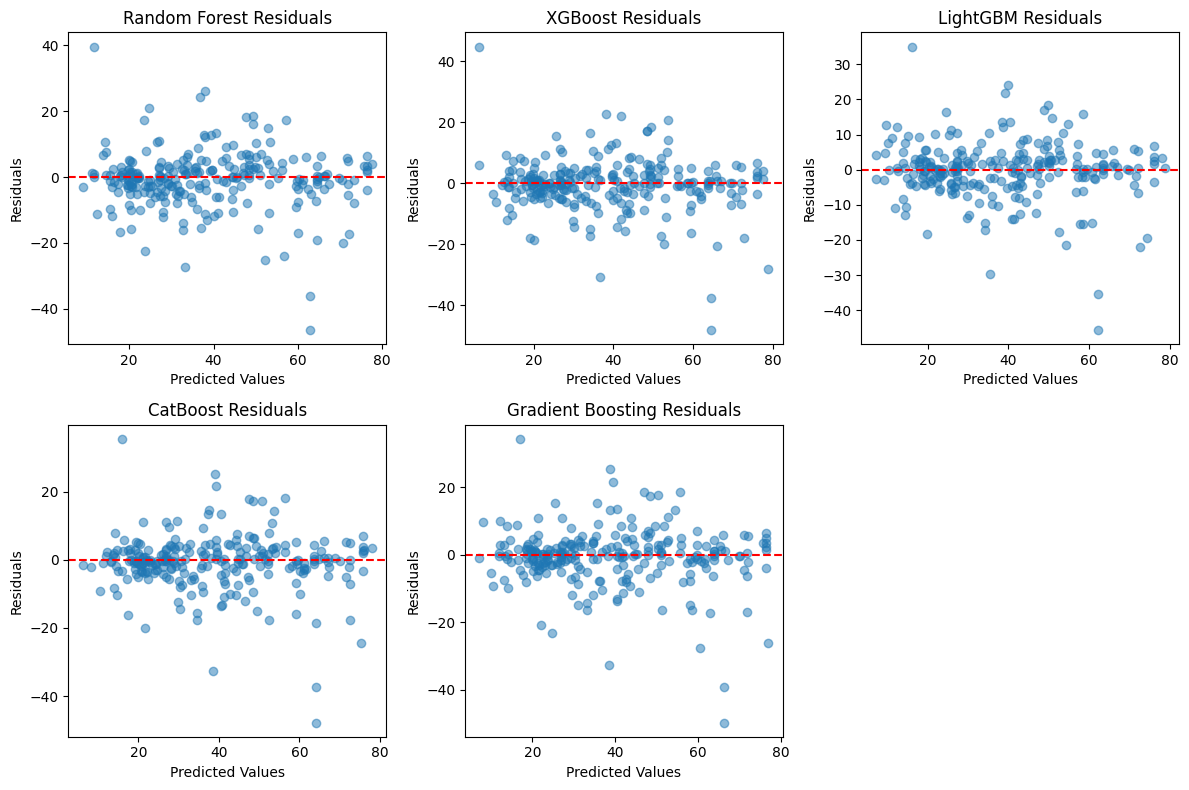

In [91]:
# residual plots for all the best tree models

tree_models_pred = {
    "Random Forest": best_rf.predict(X_test),
    "XGBoost": best_xgb.predict(X_test),
    "LightGBM": best_lgbm.predict(X_test),
    "CatBoost": best_catboost.predict(X_test),
    "Gradient Boosting": best_gb.predict(X_test)
}

plt.figure(figsize=(12, 8))
for i, (model_name, predictions) in enumerate(tree_models_pred.items()):
    residuals = y_test - predictions
    plt.subplot(2, 3, i+1)
    plt.scatter(predictions, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"{model_name} Residuals")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

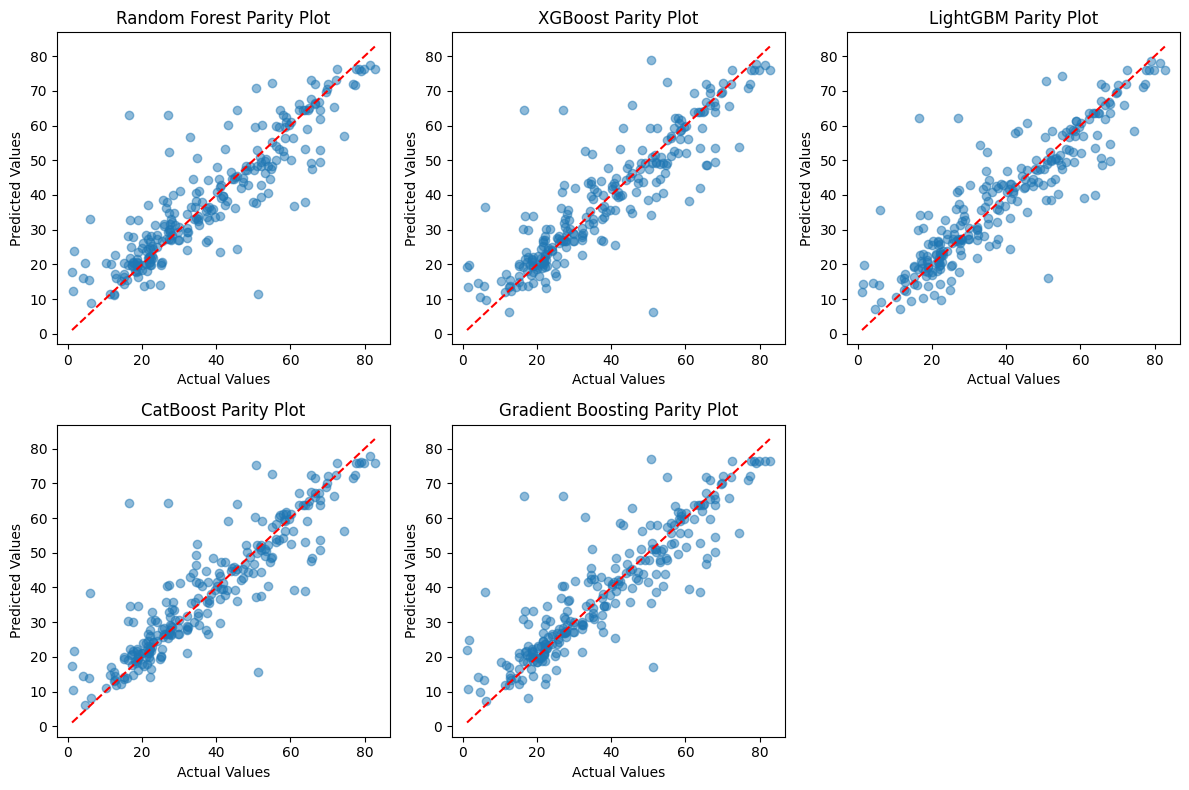

In [72]:
# parity plots for all the best tree models

plt.figure(figsize=(12, 8))
for i, (model_name, predictions) in enumerate(tree_models_pred.items()):
    plt.subplot(2, 3, i+1)
    plt.scatter(y_test, predictions, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Line for perfect predictions
    plt.title(f"{model_name} Parity Plot")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()
